## Binning

In [3]:
# Cell 1 — Imports + paths

import pandas as pd
import numpy as np
import math
from pathlib import Path

DATA_POSTS_PATH = "../data/Ambivalent_Data_Final_2.csv"
DATA_COMMENTS_PATH = "../data/Ambivalent_Comments_d0.csv"

OUT_PREVIEW_PATH = "Ambivalent_Binning_preview_5posts_d0.csv"
OUT_FULL_PATH = "Ambivalent_Binning_d0.csv"


In [4]:
# Cell 2 — Load + filter to posts that have comments

posts = pd.read_csv(DATA_POSTS_PATH)
comments = pd.read_csv(DATA_COMMENTS_PATH)

posts["post_id"] = posts["post_id"].astype(str)
comments["post_id"] = comments["post_id"].astype(str)

comments["comment_score"] = pd.to_numeric(comments["comment_score"], errors="coerce")
comments = comments.dropna(subset=["comment_score"]).copy()
comments["comment_score"] = comments["comment_score"].astype(float)

# only posts that exist in comments
post_ids_with_comments = set(comments["post_id"].unique())
posts_with_comments = posts[posts["post_id"].isin(post_ids_with_comments)].copy()

print("Posts total:", len(posts))
print("Posts with comments:", len(posts_with_comments))
print("Comments total:", len(comments))


Posts total: 1279
Posts with comments: 1098
Comments total: 2728


In [5]:
# Cell 3 — Freedman–Diaconis edges PER POST

def fd_bin_edges(x: np.ndarray) -> np.ndarray:
    """
    Return bin edges using Freedman–Diaconis rule for array x (1D).
    Uses a fallback if IQR==0 or too-few points.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return np.array([0.0, 1.0])
    if n == 1:
        return np.array([x[0], x[0] + 1e-9])

    xmin, xmax = float(np.min(x)), float(np.max(x))
    if xmin == xmax:
        return np.array([xmin, xmax + 1e-9])

    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1

    if iqr == 0:
        # fallback width
        std = float(np.std(x))
        width = std * (n ** (-1/3))
        if (not np.isfinite(width)) or width <= 0:
            width = 1.0
    else:
        width = 2 * iqr * (n ** (-1/3))

    k = int(math.ceil((xmax - xmin) / width))
    k = max(k, 1)

    edges = np.linspace(xmin, xmax, k + 1)
    edges[-1] = edges[-1] + 1e-9  # include max in left-closed bins
    return edges


In [6]:
# Cell 4 — Build per-post binned comments (then pad to max bins as columns bin01_comment..binNN_comment)

POST_COLS = [
    "post_id","subreddit","title","author","score","num_comments_listed","op_replied",
    "op_reply_count","created_utc","permalink","body","combined_text"
]

def per_post_binning(posts_subset: pd.DataFrame,
                     comments_df: pd.DataFrame,
                     max_comment_chars: int = 350):
    """
    For each post_id:
      - compute FD bins using that post's comment_scores
      - pick the lowest-score comment per bin
      - order bins by increasing score range
    Returns:
      - out_df wide with bin columns padded to max bins in this subset
      - bin_counts dict {post_id: num_bins_used}
      - max_bins used
    """
    # only comments for these posts
    ids = posts_subset["post_id"].astype(str).unique()
    c = comments_df[comments_df["post_id"].isin(ids)].copy()

    # Precompute chosen comments per post as a list (in bin order)
    chosen_map = {}
    bin_counts = {}

    for pid, g in c.groupby("post_id"):
        scores = g["comment_score"].to_numpy()
        edges = fd_bin_edges(scores)

        # assign bin index within this post
        bin_idx = pd.cut(
            g["comment_score"],
            bins=edges,
            right=False,
            include_lowest=True,
            labels=False
        )
        gg = g.copy()
        gg["bin_idx"] = bin_idx
        gg = gg.dropna(subset=["bin_idx"]).copy()
        gg["bin_idx"] = gg["bin_idx"].astype(int)

        # pick min score per bin
        gg = gg.sort_values(["bin_idx", "comment_score"], ascending=[True, True])
        picked = gg.groupby("bin_idx", as_index=False).first()

        # build labels for ranges
        intervals = pd.IntervalIndex.from_breaks(edges, closed="left")
        labels = {i: f"[{intervals[i].left:g}, {intervals[i].right:g})" for i in range(len(intervals))}

        # create ordered list of cell strings
        cells = []
        for _, row in picked.sort_values("bin_idx").iterrows():
            b = int(row["bin_idx"])
            rng = labels.get(b, "")
            score = float(row["comment_score"])
            text = str(row.get("comment_body", "")).replace("\n", " ").replace("\r", " ")
            if len(text) > max_comment_chars:
                text = text[:max_comment_chars].rstrip() + "..."
            cells.append(f"{rng} | score={score:g} | {text}")

        chosen_map[pid] = cells
        bin_counts[pid] = len(cells)

    max_bins = max(bin_counts.values()) if bin_counts else 0

    # build wide rows
    rows = []
    meta = posts_subset[POST_COLS].drop_duplicates(subset=["post_id"]).copy()

    for _, prow in meta.iterrows():
        pid = str(prow["post_id"])
        cells = chosen_map.get(pid, [])
        row = prow.to_dict()
        for j in range(max_bins):
            col = f"bin{j+1:02d}_comment"
            row[col] = cells[j] if j < len(cells) else np.nan
        rows.append(row)

    out_df = pd.DataFrame(rows)
    return out_df, bin_counts, max_bins


In [7]:
# Cell 5 — PREVIEW on first 5 posts (and save). Columns count == max bins among these 5 posts.

preview_posts = posts_with_comments.head(5).copy()
preview_out, preview_bin_counts, preview_max_bins = per_post_binning(preview_posts, comments, max_comment_chars=350)

print("Bin counts per post_id (preview):")
for k, v in preview_bin_counts.items():
    print(k, "->", v)

print("Max bins in preview subset:", preview_max_bins)
print("Preview shape:", preview_out.shape)

display(preview_out.head())

preview_out.to_csv(OUT_PREVIEW_PATH, index=False)
print("Saved preview to:", OUT_PREVIEW_PATH)


Bin counts per post_id (preview):
1bautv8 -> 2
1c09z00 -> 1
1ccnt06 -> 1
1f2kibx -> 1
1hv4zdy -> 2
Max bins in preview subset: 2
Preview shape: (5, 14)


,post_id,subreddit,title,author,score,num_comments_listed,op_replied,op_reply_count,created_utc,permalink,body,combined_text,bin01_comment,bin02_comment
0,1hv4zdy,meToo,Was this SA?,Ok-Sugar959,5.0,7.0,True,3,1.736186e+09,/r/meToo/comments/1hv4zdy/was_this_sa/,So l've been in a relationship with a girl who...,1hv4zdy meToo Was this SA? Ok-Sugar959 /r/meTo...,"[2, 2.5) | score=2 | As a woman who has been S...","[2.5, 3) | score=3 | Both SA. P.S. Keep away ..."
1,1f2kibx,meToo,Dealing with sexual assault trauma / was it SA?,Ok-Air-6389,6.0,3.0,True,1,1.724774e+09,/r/meToo/comments/1f2kibx/dealing_with_sexual_...,I went through a break up recently with my ex ...,1f2kibx meToo Dealing with sexual assault trau...,"[2, 2) | score=2 | Oh dear, that's a tough ser...",NaN
2,1ccnt06,meToo,was this sa,FlimsyImplement4042,3.0,3.0,True,1,1.714038e+09,/r/meToo/comments/1ccnt06/was_this_sa/,was this sa?\n\n\nwhen i was 7 or 8 i had my b...,1ccnt06 meToo was this sa FlimsyImplement4042 ...,"[1, 1) | score=1 | &gt;made me go in the close...",NaN
3,1c09z00,meToo,Was I sexually assaulted by my ex?,[deleted],3.0,1.0,False,0,1.712714e+09,/r/meToo/comments/1c09z00/was_i_sexually_assau...,"\nAbout seven months ago, I had been seeing so...",1c09z00 meToo Was I sexually assaulted by my e...,"[3, 3) | score=3 | Yes, it was assault. You sp...",NaN
4,1bautv8,meToo,Not sure if this counts as SA,annoyingpea,4.0,2.0,False,0,1.710025e+09,/r/meToo/comments/1bautv8/not_sure_if_this_cou...,So yesterday I was at a party and I’ve definit...,1bautv8 meToo Not sure if this counts as SA an...,"[1, 3) | score=1 | I’m so sorry this happened ...","[3, 5) | score=5 | yes, this is assault, a per..."


Saved preview to: Ambivalent_Binning_preview_5posts_d0.csv


In [8]:
# Cell 6 — FULL run (WARNING: number of columns will become max bins across ALL posts)
# If you want to CAP columns to (say) 10 globally, tell me and I’ll adjust.

full_out, full_bin_counts, full_max_bins = per_post_binning(posts_with_comments, comments, max_comment_chars=350)

print("Max bins across ALL posts:", full_max_bins)
print("Full shape:", full_out.shape)

full_out.to_csv(OUT_FULL_PATH, index=False)
print("Saved full output to:", OUT_FULL_PATH)


Max bins across ALL posts: 10
Full shape: (1012, 22)
Saved full output to: Ambivalent_Binning_d0.csv


In [10]:
# Remove "[a, b) | score=x | " prefix from all binXX_comment columns

import pandas as pd
import re

IN_PATH = "Ambivalent_Binning_d0.csv"
OUT_PATH = "Ambivalent_Binning_Clean_d0.csv"

df = pd.read_csv(IN_PATH)

bin_cols = [c for c in df.columns if re.match(r"^bin\d+_comment$", c)]

def strip_prefix(val):
    if pd.isna(val):
        return val
    s = str(val)
    # Split on " | " at most 2 times -> [range, score=..., rest_of_comment]
    parts = s.split(" | ", 2)
    if len(parts) == 3:
        return parts[2]
    return s  # if format is unexpected, leave as-is

for c in bin_cols:
    df[c] = df[c].apply(strip_prefix)

df.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Example (before/after) check on first non-null cell:")
for c in bin_cols:
    sample = df[c].dropna()
    if len(sample) > 0:
        print(c, "->", sample.iloc[0][:120], "...")
        break


Saved: Ambivalent_Binning_Clean_d0.csv
Example (before/after) check on first non-null cell:
bin01_comment -> As a woman who has been SA’d multiple times, I sympathize with the situation but no, you did not SA her.   You guys were ...


## Variable number of bins 

In [1]:
import re
import numpy as np
import pandas as pd

IN_PATH = "Ambivalent_Binning_with_IRA.csv"   # or your file that contains ira_* columns + binXX_comment cols
df = pd.read_csv(IN_PATH)

# ---- 1) Count bins per row = number of non-empty binXX_comment cells ----
bin_cols = sorted(
    [c for c in df.columns if re.match(r"^bin\d+_comment$", str(c))],
    key=lambda x: int(re.findall(r"\d+", x)[0])
)

def is_filled(x):
    if pd.isna(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() != "nan"

df["n_bins"] = df[bin_cols].apply(lambda row: sum(is_filled(v) for v in row), axis=1)

print("n_bins summary:")
print(df["n_bins"].describe())

# ---- 2) Compute Q25/Q50/Q75 on n_bins ----
q25, q50, q75 = df["n_bins"].quantile([0.25, 0.50, 0.75]).tolist()
print("\nQuartiles for n_bins")
print("Q25:", q25, " Q50:", q50, " Q75:", q75)

# ---- 3) Option C-style bucketing by proportion (always 3 groups), based on n_bins ----
# This guarantees you get Low/Moderate/High even if many ties in n_bins.
pct_bins = df["n_bins"].rank(pct=True, method="average")

df["bin_bucket_3"] = pd.cut(
    pct_bins,
    bins=[0.0, 0.25, 0.75, 1.0],
    labels=["Low (#bins)", "Moderate (#bins)", "High (#bins)"],
    include_lowest=True
)

# (Optional) 4 buckets by proportion (quartiles)
df["bin_bucket_4"] = pd.cut(
    pct_bins,
    bins=[0.0, 0.25, 0.50, 0.75, 1.0],
    labels=["Q1 bins", "Q2 bins", "Q3 bins", "Q4 bins"],
    include_lowest=True
)

print("\nCounts (3-bucket):")
print(df["bin_bucket_3"].value_counts(dropna=False))

# ---- 4) Compare IRA across these buckets ----
ALIGN_COL = "ira_kendall_tau_b"   # or "ira_spearman_rho"
use = df[(df.get("ira_valid", True) == True) & df[ALIGN_COL].notna()].copy()

print("\nMean IRA by 3-bucket:")
print(use.groupby("bin_bucket_3")[ALIGN_COL].agg(["count", "mean", "std"]))

print("\nMean IRA by 4-bucket:")
print(use.groupby("bin_bucket_4")[ALIGN_COL].agg(["count", "mean", "std"]))

# ---- 5) Save ----
OUT_PATH = "Ambivalent_with_binCount_buckets_and_IRA.csv"
df.to_csv(OUT_PATH, index=False)
print("\nSaved:", OUT_PATH)


n_bins summary:
count    407.000000
mean       2.314496
std        0.850593
min        2.000000
25%        2.000000
50%        2.000000
75%        2.000000
max       10.000000
Name: n_bins, dtype: float64

Quartiles for n_bins
Q25: 2.0  Q50: 2.0  Q75: 2.0

Counts (3-bucket):
bin_bucket_3
Moderate (#bins)    332
High (#bins)         75
Low (#bins)           0
Name: count, dtype: int64

Mean IRA by 3-bucket:
                  count      mean       std
bin_bucket_3                               
Low (#bins)           0       NaN       NaN
Moderate (#bins)    332  0.313253  0.951103
High (#bins)         75  0.232148  0.599746

Mean IRA by 4-bucket:
              count      mean       std
bin_bucket_4                           
Q1 bins           0       NaN       NaN
Q2 bins         332  0.313253  0.951103
Q3 bins           0       NaN       NaN
Q4 bins          75  0.232148  0.599746


/tmp/ipykernel_22377/2565525868.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(use.groupby("bin_bucket_3")[ALIGN_COL].agg(["count", "mean", "std"]))
/tmp/ipykernel_22377/2565525868.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(use.groupby("bin_bucket_4")[ALIGN_COL].agg(["count", "mean", "std"]))



Saved: Ambivalent_with_binCount_buckets_and_IRA.csv


In [2]:
import re
import numpy as np
import pandas as pd

IN_PATH = "Ambivalent_Binning_with_IRA.csv"   # must include ira_* and binXX_comment columns
df = pd.read_csv(IN_PATH)

# 1) count number of filled bin columns per row
bin_cols = sorted(
    [c for c in df.columns if re.match(r"^bin\d+_comment$", str(c))],
    key=lambda x: int(re.findall(r"\d+", x)[0])
)

def is_filled(x):
    if pd.isna(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() != "nan"

df["n_bins"] = df[bin_cols].apply(lambda row: sum(is_filled(v) for v in row), axis=1)

print(df["n_bins"].value_counts().sort_index())

# 2) bucket by actual n_bins values (robust to ties)
def bucket_nbins(k):
    if k <= 2:
        return "Low (2 bins)"
    elif k == 3:
        return "Moderate (3 bins)"
    else:
        return "High (4+ bins)"

df["bin_bucket_3"] = df["n_bins"].apply(bucket_nbins)

print("\nCounts:")
print(df["bin_bucket_3"].value_counts(dropna=False))

# 3) compare IRA across buckets
ALIGN_COL = "ira_kendall_tau_b"   # or "ira_spearman_rho"
use = df[(df.get("ira_valid", True) == True) & df[ALIGN_COL].notna()].copy()

print("\nMean IRA by bucket:")
print(use.groupby("bin_bucket_3")[ALIGN_COL].agg(["count", "mean", "std"]))

# Optional: also show median (often better when distributions are spiky)
print("\nMedian IRA by bucket:")
print(use.groupby("bin_bucket_3")[ALIGN_COL].median())

OUT_PATH = "Ambivalent_with_nBinsBuckets_and_IRA.csv"
df.to_csv(OUT_PATH, index=False)
print("\nSaved:", OUT_PATH)


n_bins
2     332
3      44
4      21
5       5
6       3
9       1
10      1
Name: count, dtype: int64

Counts:
bin_bucket_3
Low (2 bins)         332
Moderate (3 bins)     44
High (4+ bins)        31
Name: count, dtype: int64

Mean IRA by bucket:
                   count      mean       std
bin_bucket_3                                
High (4+ bins)        31  0.239068  0.455374
Low (2 bins)         332  0.313253  0.951103
Moderate (3 bins)     44  0.227273  0.688678

Median IRA by bucket:
bin_bucket_3
High (4+ bins)       0.277778
Low (2 bins)         1.000000
Moderate (3 bins)    0.333333
Name: ira_kendall_tau_b, dtype: float64

Saved: Ambivalent_with_nBinsBuckets_and_IRA.csv


In [3]:
import numpy as np
import pandas as pd

# assumes df["n_bins"] exists
x = df["n_bins"].dropna()

# 1) Try qcut into 3 groups, dropping duplicate edges
try:
    df.loc[x.index, "n_bins_qcut3"] = pd.qcut(
        x.rank(method="first"),              # "first" breaks ties deterministically
        q=[0, 1/3, 2/3, 1],
        labels=["Low", "Moderate", "High"],
        duplicates="drop"
    )
    # If qcut dropped bins, you'll get fewer categories; check
    cats = df["n_bins_qcut3"].dropna().unique()
    print("qcut3 categories produced:", sorted(list(cats)))
except Exception as e:
    print("qcut3 failed, falling back. Error:", e)
    df["n_bins_qcut3"] = np.nan

# 2) If qcut collapsed to <3 groups (or failed), fall back to discrete bins
num_groups = df["n_bins_qcut3"].nunique(dropna=True)
if num_groups < 3:
    print("qcut3 produced", num_groups, "groups; using fallback discrete grouping instead.")

    def fallback_group(k):
        k = int(k)
        if k <= 2: return "Low"
        if k == 3: return "Moderate"
        return "High"

    df["n_bins_qcut3"] = df["n_bins"].apply(lambda v: fallback_group(v) if pd.notna(v) else np.nan)

print("\nFinal group counts:")
print(df["n_bins_qcut3"].value_counts(dropna=False))


qcut3 categories produced: ['High', 'Low', 'Moderate']

Final group counts:
n_bins_qcut3
Low         136
High        136
Moderate    135
Name: count, dtype: int64


In [4]:
import numpy as np
import pandas as pd

# =========================
# Assumes df["n_bins"] exists
# If not, compute it BEFORE running these options.
# =========================
# Basic cleanup
df["n_bins"] = pd.to_numeric(df["n_bins"], errors="coerce")
x = df["n_bins"].dropna().astype(int)

print("n_bins value counts:\n", x.value_counts().sort_index())
print("min/max:", int(x.min()), int(x.max()), "N:", len(x))

n_bins value counts:
 n_bins
2     332
3      44
4      21
5       5
6       3
9       1
10      1
Name: count, dtype: int64
min/max: 2 10 N: 407


In [5]:
def add_qcut3(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    x = df["n_bins"].dropna().astype(int)

    # rank(method="first") breaks ties deterministically so qcut can split into thirds
    df.loc[x.index, "n_bins_qcut3"] = pd.qcut(
        x.rank(method="first"),
        q=[0, 1/3, 2/3, 1],
        labels=["Low", "Moderate", "High"],
        duplicates="drop"
    )

    # Safety: if it still collapses (rare), fall back to a simple count-based grouping
    if df["n_bins_qcut3"].nunique(dropna=True) < 3:
        def fallback(k):
            k = int(k)
            if k <= 2: return "Low"
            if k == 3: return "Moderate"
            return "High"
        df["n_bins_qcut3"] = df["n_bins"].apply(lambda v: fallback(v) if pd.notna(v) else np.nan)

    return df

df_opt1 = add_qcut3(df)
print("\n[Option 1] n_bins_qcut3 counts:")
print(df_opt1["n_bins_qcut3"].value_counts(dropna=False))


[Option 1] n_bins_qcut3 counts:
n_bins_qcut3
Low         136
High        136
Moderate    135
Name: count, dtype: int64


In [6]:
# ============================================================
# # OPTION 2) Sturges/Rice: choose K bins, then equal-width cut
# (Produces decimal ranges; works without errors)
# ============================================================
def add_sturges_bins(df_in: pd.DataFrame, rule: str = "sturges") -> pd.DataFrame:
    df = df_in.copy()
    x = df["n_bins"].dropna().astype(int)
    N = len(x)

    K_sturges = int(np.ceil(np.log2(N) + 1))
    K_rice = int(np.ceil(2 * (N ** (1/3))))

    if rule.lower() == "rice":
        K = K_rice
    else:
        K = K_sturges

    # Ensure K is at least 2
    K = max(2, K)

    edges = np.linspace(x.min(), x.max() + 1, K + 1)  # +1 so max included
    df["n_bins_sturges_bin"] = pd.cut(df["n_bins"], bins=edges, include_lowest=True)

    print(f"\n[Option 2] Rule={rule}  N={N}  K_sturges={K_sturges}  K_rice={K_rice}  Using K={K}")
    print(df["n_bins_sturges_bin"].value_counts(dropna=False).sort_index())
    return df

df_opt2 = add_sturges_bins(df, rule="sturges")
# df_opt2_rice = add_sturges_bins(df, rule="rice")   # optional


[Option 2] Rule=sturges  N=407  K_sturges=10  K_rice=15  Using K=10
n_bins_sturges_bin
(1.999, 2.9]    332
(2.9, 3.8]       44
(3.8, 4.7]       21
(4.7, 5.6]        5
(5.6, 6.5]        3
(6.5, 7.4]        0
(7.4, 8.3]        0
(8.3, 9.2]        1
(9.2, 10.1]       1
(10.1, 11.0]      0
Name: count, dtype: int64


In [7]:
# ============================================================
# OPTION 3) Integer-aligned bins (best for count variables)
# One bin for each integer count: [2,3), [3,4), ...
# ============================================================
def add_integer_bins(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    x = df["n_bins"].dropna().astype(int)

    edges = np.arange(x.min(), x.max() + 2)  # +2 so max included as last edge
    df["n_bins_int_bin"] = pd.cut(df["n_bins"], bins=edges, right=False, include_lowest=True)

    print("\n[Option 3] n_bins_int_bin counts:")
    print(df["n_bins_int_bin"].value_counts(dropna=False).sort_index())
    return df

df_opt3 = add_integer_bins(df)


# ============================================================
# OPTION 4) Coarse, interpretable bins (matches your distribution well)
# Example: 2 bins, 3 bins, 4+ bins
# ============================================================
def add_coarse_bins(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()
    # bins: (1.5,2.5] -> 2, (2.5,3.5] -> 3, (3.5, inf] -> 4+
    bins = [1.5, 2.5, 3.5, np.inf]
    labels = ["2 bins", "3 bins", "4+ bins"]
    df["n_bins_coarse"] = pd.cut(df["n_bins"], bins=bins, labels=labels, include_lowest=True)

    print("\n[Option 4] n_bins_coarse counts:")
    print(df["n_bins_coarse"].value_counts(dropna=False))
    return df

df_opt4 = add_coarse_bins(df)



[Option 3] n_bins_int_bin counts:
n_bins_int_bin
[2, 3)      332
[3, 4)       44
[4, 5)       21
[5, 6)        5
[6, 7)        3
[7, 8)        0
[8, 9)        0
[9, 10)       1
[10, 11)      1
Name: count, dtype: int64

[Option 4] n_bins_coarse counts:
n_bins_coarse
2 bins     332
3 bins      44
4+ bins     31
Name: count, dtype: int64


In [8]:
import re
import numpy as np
import pandas as pd

# =========================
# 0) Load your data
# =========================
IN_PATH = "Ambivalent_Binning_with_IRA.csv"  # change if your file name differs
df = pd.read_csv(IN_PATH)

# =========================
# 1) Ensure n_bins exists (compute from binXX_comment columns if missing)
# =========================
if "n_bins" not in df.columns:
    bin_cols = sorted(
        [c for c in df.columns if re.match(r"^bin\d+_comment$", str(c))],
        key=lambda x: int(re.findall(r"\d+", x)[0])
    )

    def is_filled(x):
        if pd.isna(x):
            return False
        s = str(x).strip()
        return s != "" and s.lower() != "nan"

    df["n_bins"] = df[bin_cols].apply(lambda row: sum(is_filled(v) for v in row), axis=1)

print("Loaded:", IN_PATH, "| rows:", len(df), "| n_bins min/max:", df["n_bins"].min(), df["n_bins"].max())

# =========================
# 2) Freedman–Diaconis binning on n_bins
# =========================
x = pd.to_numeric(df["n_bins"], errors="coerce").dropna().astype(float).values

def fd_edges(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    xmin, xmax = float(np.min(x)), float(np.max(x))

    if n < 2 or xmin == xmax:
        edges = np.array([xmin, xmax + 1e-9])
        return edges, np.nan, np.nan, np.nan, np.nan, n

    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25

    # FD bin width
    if iqr == 0:
        h = 1.0
    else:
        h = 2 * iqr / (n ** (1/3))

    # For integer count data, avoid tiny fractional bins
    h = max(h, 1.0)

    edges = np.arange(xmin, xmax + h, h)
    if edges[-1] < xmax + 1e-9:
        edges = np.append(edges, xmax + 1e-9)

    return edges, h, q25, q75, iqr, n

edges, h, q25, q75, iqr, n = fd_edges(x)

print("\nFD details for n_bins:")
print("N:", n, "Q25:", q25, "Q75:", q75, "IQR:", iqr, "h (bin width):", h)
print("Bins:", len(edges) - 1)
print("Edges:", edges)

df["n_bins_fd_bin"] = pd.cut(
    df["n_bins"],
    bins=edges,
    include_lowest=True,
    duplicates="drop"
)

print("\nFD bin counts:")
print(df["n_bins_fd_bin"].value_counts(dropna=False).sort_index())

OUT_PATH = "with_nbins_fd_bins.csv"
df.to_csv(OUT_PATH, index=False)
print("\nSaved:", OUT_PATH)


Loaded: Ambivalent_Binning_with_IRA.csv | rows: 407 | n_bins min/max: 2 10

FD details for n_bins:
N: 407 Q25: 2.0 Q75: 2.0 IQR: 0.0 h (bin width): 1.0
Bins: 9
Edges: [ 2.  3.  4.  5.  6.  7.  8.  9. 10. 10.]

FD bin counts:
n_bins_fd_bin
(1.999999999, 3.0]      376
(3.0, 4.0]               21
(4.0, 5.0]                5
(5.0, 6.0]                3
(6.0, 7.0]                0
(7.0, 8.0]                0
(8.0, 9.0]                1
(9.0, 10.0]               1
(10.0, 10.000000001]      0
Name: count, dtype: int64

Saved: with_nbins_fd_bins.csv


In [9]:
import numpy as np
import pandas as pd

# Load the file that has n_bins (change if needed)
df = pd.read_csv("with_nbins_fd_bins.csv")

# Ensure integer
df["n_bins"] = pd.to_numeric(df["n_bins"], errors="coerce")
x = df["n_bins"].dropna().astype(int)

print("n_bins value counts:")
print(x.value_counts().sort_index())

q25, q50, q75 = x.quantile([0.25, 0.50, 0.75]).tolist()
print("\nQuartiles for n_bins:")
print("Q25:", q25)
print("Q50:", q50)
print("Q75:", q75)


n_bins value counts:
n_bins
2     332
3      44
4      21
5       5
6       3
9       1
10      1
Name: count, dtype: int64

Quartiles for n_bins:
Q25: 2.0
Q50: 2.0
Q75: 2.0


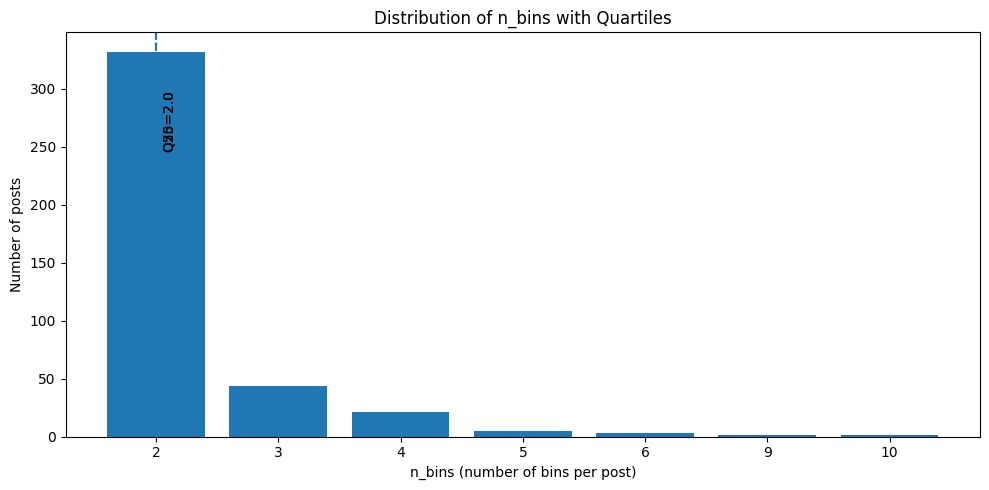

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = df["n_bins"].dropna().astype(int)

q25, q50, q75 = x.quantile([0.25, 0.50, 0.75]).tolist()

# Bar chart of counts for each integer n_bins
counts = x.value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(counts.index.astype(str), counts.values)

plt.title("Distribution of n_bins with Quartiles")
plt.xlabel("n_bins (number of bins per post)")
plt.ylabel("Number of posts")

# Add quartile lines (mapped onto the x-axis scale)
# We draw them as vertical lines using numeric positions.
# Convert x labels (integers) to positions 0..len-1
xs = counts.index.to_list()
pos = {v:i for i,v in enumerate(xs)}

def vline_at(val, label):
    # If quartile lands exactly on an integer (likely), draw at that integer’s bar center
    if val in pos:
        plt.axvline(pos[val], linestyle="--")
        plt.text(pos[val] + 0.05, max(counts.values)*0.9, label, rotation=90, va="top")
    else:
        # if it’s fractional, approximate between bars
        # find nearest lower integer bin
        lower = max([k for k in xs if k <= val], default=xs[0])
        plt.axvline(pos[lower], linestyle="--")
        plt.text(pos[lower] + 0.05, max(counts.values)*0.9, label, rotation=90, va="top")

vline_at(int(q25), f"Q25={q25}")
vline_at(int(q50), f"Q50={q50}")
vline_at(int(q75), f"Q75={q75}")

plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("with_nbins_fd_bins.csv")  # change if needed
df["n_bins"] = pd.to_numeric(df["n_bins"], errors="coerce")
x = df["n_bins"].dropna().astype(int)

# Show distribution
print("n_bins value counts:")
print(x.value_counts().sort_index())

# Quartiles + higher percentiles
qs = [0.25, 0.50, 0.75, 0.80, 0.85, 0.90, 0.95]
vals = x.quantile(qs)

print("\nPercentiles for n_bins:")
for q in qs:
    print(f"Q{int(q*100):02d}:", float(vals.loc[q]))


n_bins value counts:
n_bins
2     332
3      44
4      21
5       5
6       3
9       1
10      1
Name: count, dtype: int64

Percentiles for n_bins:
Q25: 2.0
Q50: 2.0
Q75: 2.0
Q80: 2.0
Q85: 3.0
Q90: 3.0
Q95: 4.0


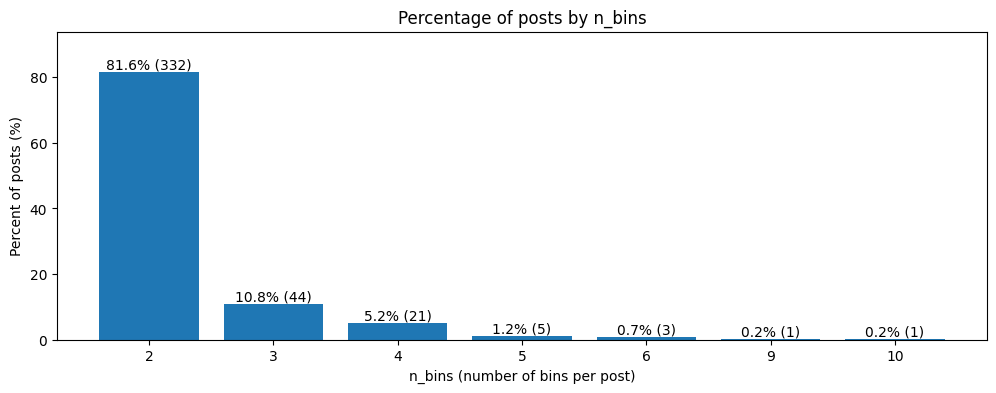

 n_bins  count  percent
      2    332    81.57
      3     44    10.81
      4     21     5.16
      5      5     1.23
      6      3     0.74
      9      1     0.25
     10      1     0.25


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# counts + percents
counts = df["n_bins"].value_counts().sort_index()
total = counts.sum()
perc = counts / total * 100

plt.figure(figsize=(12,4))
bars = plt.bar(counts.index.astype(str), perc.values)
plt.title("Percentage of posts by n_bins")
plt.xlabel("n_bins (number of bins per post)")
plt.ylabel("Percent of posts (%)")

# add labels on bars: "81.6% (332)"
for b, p, c in zip(bars, perc.values, counts.values):
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{p:.1f}% ({c})",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, max(perc.values)*1.15)
plt.show()

# also print the table
summary = (
    pd.DataFrame({"count": counts, "percent": perc.round(2)})
    .reset_index()
    .rename(columns={"index": "n_bins"})
)
print(summary.to_string(index=False))


In [14]:
import numpy as np
import pandas as pd

# Load the file that already has IRA columns + n_bins (or binXX_comment cols)
df = pd.read_csv("Ambivalent_Binning_with_IRA.csv")

ALIGN_COL = "ira_kendall_tau_b"   # or "ira_spearman_rho"

# If n_bins is not already present, compute it from binXX_comment columns
if "n_bins" not in df.columns:
    import re
    bin_cols = [c for c in df.columns if re.match(r"^bin\d+_comment$", str(c))]
    def is_filled(x):
        if pd.isna(x): return False
        s = str(x).strip()
        return s != "" and s.lower() != "nan"
    df["n_bins"] = df[bin_cols].apply(lambda r: sum(is_filled(v) for v in r), axis=1)

# Bucket: low=2, moderate=3, high=4+
def nb_bucket(k):
    if pd.isna(k): return np.nan
    k = int(k)
    if k == 2: return "Low (2)"
    if k == 3: return "Moderate (3)"
    if k >= 4: return "High (4+)"
    return "Other (<2)"   # if you have 1-bin cases, they land here

df["n_bins_bucket"] = df["n_bins"].apply(nb_bucket)

# Keep only rows with IRA available
use = df[(df.get("ira_valid", True) == True) & df[ALIGN_COL].notna()].copy()

# Summary IRA per bucket
summary = (
    use.groupby("n_bins_bucket", observed=True)[ALIGN_COL]
       .agg(count="count", mean="mean", median="median", std="std")
       .reset_index()
       .sort_values("n_bins_bucket")
)

print(summary.to_string(index=False))

# Optional: save bucketed file
OUT_PATH = "Ambivalent_Binning_with_IRA_and_nBinsBuckets.csv"
df.to_csv(OUT_PATH, index=False)
print("\nSaved:", OUT_PATH)

# sanity: show IRA by exact n_bins (or n_used_for_ira) not just bucket
print(use.groupby("n_bins", observed=True)[ALIGN_COL].agg(["count","mean","median","std"]))

# optional: compare only n_bins >= 3
use_ge3 = use[use["n_bins"] >= 3]
print("\nOnly n_bins>=3:")
print(use_ge3.groupby("n_bins_bucket", observed=True)[ALIGN_COL].agg(["count","mean","median","std"]))


n_bins_bucket  count     mean   median      std
    High (4+)     31 0.239068 0.277778 0.455374
      Low (2)    332 0.313253 1.000000 0.951103
 Moderate (3)     44 0.227273 0.333333 0.688678

Saved: Ambivalent_Binning_with_IRA_and_nBinsBuckets.csv
        count      mean    median       std
n_bins                                     
2         332  0.313253  1.000000  0.951103
3          44  0.227273  0.333333  0.688678
4          21  0.206349  0.000000  0.521496
5           5  0.320000  0.400000  0.334664
6           3  0.200000  0.200000  0.266667
9           1  0.277778  0.277778       NaN
10          1  0.600000  0.600000       NaN

Only n_bins>=3:
               count      mean    median       std
n_bins_bucket                                     
High (4+)         31  0.239068  0.277778  0.455374
Moderate (3)      44  0.227273  0.333333  0.688678


In [15]:
import numpy as np
import pandas as pd

df = pd.read_csv("Ambivalent_Binning_with_IRA.csv")

ALIGN_COL = "ira_kendall_tau_b"   # or "ira_spearman_rho"

# If n_bins is not already present, compute it from binXX_comment columns
if "n_bins" not in df.columns:
    import re
    bin_cols = [c for c in df.columns if re.match(r"^bin\d+_comment$", str(c))]

    def is_filled(x):
        if pd.isna(x): return False
        s = str(x).strip()
        return s != "" and s.lower() != "nan"

    df["n_bins"] = df[bin_cols].apply(lambda r: sum(is_filled(v) for v in r), axis=1)

# NEW bucket: low=2, moderate=3-4, high=5+
def nb_bucket(k):
    if pd.isna(k): return np.nan
    k = int(k)
    if k == 2: return "Low (2)"
    if k in (3, 4): return "Moderate (3-4)"
    if k >= 5: return "High (5+)"
    return "Other (<2)"   # if any 0/1-bin rows exist

df["n_bins_bucket"] = df["n_bins"].apply(nb_bucket)

# Keep only rows with IRA available AND (optionally) ignore n_bins<2
use = df[
    (df.get("ira_valid", True) == True) &
    df[ALIGN_COL].notna() &
    (df["n_bins"] >= 2)
].copy()

# Summary IRA per bucket
summary = (
    use.groupby("n_bins_bucket", observed=True)[ALIGN_COL]
       .agg(count="count", mean="mean", median="median", std="std")
       .reset_index()
       .sort_values("n_bins_bucket")
)

print(summary.to_string(index=False))

# Optional: save bucketed file
OUT_PATH = "Ambivalent_Binning_with_IRA_and_nBinsBuckets_2_34_5plus.csv"
df.to_csv(OUT_PATH, index=False)
print("\nSaved:", OUT_PATH)

# sanity: show IRA by exact n_bins
print("\nIRA by exact n_bins:")
print(use.groupby("n_bins", observed=True)[ALIGN_COL].agg(["count","mean","median","std"]))


 n_bins_bucket  count     mean   median      std
     High (5+)     10 0.307778 0.338889 0.281289
       Low (2)    332 0.313253 1.000000 0.951103
Moderate (3-4)     65 0.220513 0.333333 0.635405

Saved: Ambivalent_Binning_with_IRA_and_nBinsBuckets_2_34_5plus.csv

IRA by exact n_bins:
        count      mean    median       std
n_bins                                     
2         332  0.313253  1.000000  0.951103
3          44  0.227273  0.333333  0.688678
4          21  0.206349  0.000000  0.521496
5           5  0.320000  0.400000  0.334664
6           3  0.200000  0.200000  0.266667
9           1  0.277778  0.277778       NaN
10          1  0.600000  0.600000       NaN


In [21]:
import numpy as np
import pandas as pd

df = pd.read_csv("with_nbins_fd_bins.csv")

# Rank n_bins to break ties, then terciles
pct = df["n_bins"].rank(method="first", pct=True)

df["n_bins_fd_LMH_balanced"] = pd.cut(
    pct,
    bins=[0.0, 1/3, 2/3, 1.0],
    labels=["Low", "Moderate", "High"],
    include_lowest=True
)

print(df["n_bins_fd_LMH_balanced"].value_counts(dropna=False))

df.to_csv("with_nbins_fd_bins_LMH_balanced.csv", index=False)
print("Saved: with_nbins_fd_bins_LMH_balanced.csv")


n_bins_fd_LMH_balanced
Moderate    136
High        136
Low         135
Name: count, dtype: int64
Saved: with_nbins_fd_bins_LMH_balanced.csv


## Different variation of upvotes

In [22]:
import re
import numpy as np
import pandas as pd

BIN_PATH = "./csv files/Ambivalent_Binning_d0.csv"
IRA_PATH = "Ambivalent_Binning_with_IRA.csv"   # must contain post_id + ira_valid + ira_kendall_tau_b

bin_df = pd.read_csv(BIN_PATH)
ira_df = pd.read_csv(IRA_PATH)

# bin columns
bin_cols = sorted(
    [c for c in bin_df.columns if re.match(r"^bin\d+_comment$", str(c))],
    key=lambda x: int(re.findall(r"\d+", x)[0])
)

score_pat = re.compile(r"\|\s*score\s*=\s*(-?\d+)\s*\|", flags=re.IGNORECASE)

def extract_score(cell):
    if pd.isna(cell): 
        return np.nan
    m = score_pat.search(str(cell))
    return float(m.group(1)) if m else np.nan

for c in bin_cols:
    bin_df[c + "_score"] = bin_df[c].apply(extract_score)

score_cols = [c + "_score" for c in bin_cols]

print("Bin cols:", len(bin_cols))
print("Score cols:", len(score_cols))
print("Example extracted scores (row 0):", bin_df.loc[0, score_cols].dropna().tolist())


Bin cols: 10
Score cols: 10
Example extracted scores (row 0): [np.float64(2.0), np.float64(3.0)]


In [23]:
def row_vals(row):
    vals = row[score_cols].to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    return vals

bin_df["n_bins"] = bin_df[score_cols].notna().sum(axis=1)

# features
bin_df["binScore_mean"] = np.nan
bin_df["binScore_std"] = np.nan
bin_df["binScore_iqr"] = np.nan
bin_df["binScore_range"] = np.nan

for i, r in bin_df.iterrows():
    vals = row_vals(r)
    if len(vals) == 0:
        continue
    q25 = np.percentile(vals, 25)
    q75 = np.percentile(vals, 75)
    bin_df.at[i, "binScore_mean"] = float(np.mean(vals))
    bin_df.at[i, "binScore_std"] = float(np.std(vals, ddof=1)) if len(vals) >= 2 else 0.0
    bin_df.at[i, "binScore_iqr"] = float(q75 - q25)
    bin_df.at[i, "binScore_range"] = float(np.max(vals) - np.min(vals))

bin_df[["post_id","n_bins","binScore_mean","binScore_std","binScore_iqr","binScore_range"]].head()


,post_id,n_bins,binScore_mean,binScore_std,binScore_iqr,binScore_range
0,1hv4zdy,2,2.5,0.707107,0.5,1.0
1,1f2kibx,1,2.0,0.000000,0.0,0.0
2,1ccnt06,1,1.0,0.000000,0.0,0.0
3,1c09z00,1,3.0,0.000000,0.0,0.0
4,1bautv8,2,3.0,2.828427,2.0,4.0


In [24]:
ALIGN_COL = "ira_kendall_tau_b"
DIST_COL  = "binScore_iqr"   # can switch to binScore_std / binScore_range / binScore_mean

use = bin_df.merge(
    ira_df[["post_id", "ira_valid", ALIGN_COL]],
    on="post_id",
    how="inner"
)

# ignore n_bins=1
use_f = use[
    (use["n_bins"] >= 2) &
    (use["ira_valid"] == True) &
    use[ALIGN_COL].notna() &
    use[DIST_COL].notna()
].copy()

print("Rows after removing n_bins=1:", len(use_f))
print("n_bins distribution:\n", use_f["n_bins"].value_counts().sort_index())

use_f["upvoteVar_bucket_q4"] = pd.qcut(
    use_f[DIST_COL].rank(method="first"),
    q=[0, 0.25, 0.50, 0.75, 1.0],
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"],
    duplicates="drop"
)

print("\nCounts per bucket:")
print(use_f["upvoteVar_bucket_q4"].value_counts())

print("\nAlignment by bucket:")
print(use_f.groupby("upvoteVar_bucket_q4", observed=True)[ALIGN_COL].agg(["count","mean","median","std"]))

# ---- NEW: print IQR ranges per quartile bucket (actual DIST_COL value ranges) ----
print("\nIQR ranges per quartile bucket (on actual", DIST_COL, "values):")
iqr_ranges = (
    use_f.groupby("upvoteVar_bucket_q4", observed=True)[DIST_COL]
        .agg(
            count="count",
            min_val="min",
            q25=lambda s: s.quantile(0.25),
            median="median",
            q75=lambda s: s.quantile(0.75),
            max_val="max",
        )
        .reset_index()
)

print(iqr_ranges.to_string(index=False))

# ---- OPTIONAL: print global quartile thresholds of DIST_COL (not equal-sized qcut buckets) ----
q25, q50, q75 = use_f[DIST_COL].quantile([0.25, 0.50, 0.75]).tolist()
print("\nGlobal", DIST_COL, "thresholds:")
print("Q25 =", q25, " Q50 =", q50, " Q75 =", q75)


Rows after removing n_bins=1: 407
n_bins distribution:
 n_bins
2     332
3      44
4      21
5       5
6       3
9       1
10      1
Name: count, dtype: int64

Counts per bucket:
upvoteVar_bucket_q4
Q1 (lowest)     102
Q2              102
Q4 (highest)    102
Q3              101
Name: count, dtype: int64

Alignment by bucket:
                     count      mean    median       std
upvoteVar_bucket_q4                                     
Q1 (lowest)            102  0.215686  1.000000  0.981285
Q2                     102  0.352941  1.000000  0.926120
Q3                     101  0.290429  1.000000  0.924558
Q4 (highest)           102  0.334096  0.533333  0.744224

IQR ranges per quartile bucket (on actual binScore_iqr values):
upvoteVar_bucket_q4  count  min_val  q25  median  q75  max_val
        Q1 (lowest)    102      0.5  0.5    0.50  0.5      0.5
                 Q2    102      0.5  0.5    0.75  1.0      1.0
                 Q3    101      1.0  1.5    1.50  2.0      2.5
       Q4 (hig

In [25]:
import numpy as np
import pandas as pd

ALIGN_COL = "ira_kendall_tau_b"

score_cols = [c for c in bin_df.columns if c.endswith("_comment_score")]
score_cols = sorted(score_cols, key=lambda x: int("".join([ch for ch in x if ch.isdigit()]) or 0))

def dist_features(row):
    vals = row[score_cols].to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return pd.Series(dtype=float)

    vals_sorted = np.sort(vals)
    mn, mx = float(vals_sorted[0]), float(vals_sorted[-1])
    rng = mx - mn
    mean = float(np.mean(vals_sorted))
    med = float(np.median(vals_sorted))
    std = float(np.std(vals_sorted, ddof=1)) if len(vals_sorted) >= 2 else 0.0
    var = std**2

    q25 = float(np.percentile(vals_sorted, 25))
    q75 = float(np.percentile(vals_sorted, 75))
    iqr = q75 - q25

    # outlier-ness proxies
    tail_ratio = (mx / med) if med != 0 else np.inf
    top_gap = mx - q75

    return pd.Series({
        "up_min": mn,
        "up_max": mx,
        "up_range": rng,
        "up_mean": mean,
        "up_median": med,
        "up_std": std,
        "up_var": var,
        "up_iqr": iqr,
        "up_tail_ratio": tail_ratio,
        "up_top_gap": top_gap,
        "n_scores": len(vals_sorted)
    })

feat = bin_df[["post_id","n_bins"]].copy()
feat = pd.concat([feat, bin_df.apply(dist_features, axis=1)], axis=1)

# merge IRA
use = feat.merge(
    ira_df[["post_id","ira_valid",ALIGN_COL]],
    on="post_id",
    how="inner"
)

# optional: ignore n_bins=1 (recommended)
use = use[(use["n_bins"] >= 2) & (use["ira_valid"] == True) & use[ALIGN_COL].notna()].copy()

def dist_type(r):
    rng = r["up_range"]
    iqr = r["up_iqr"]
    tail = r["up_tail_ratio"]
    top_gap = r["up_top_gap"]

    # 1) flat / tight
    if (rng <= 2) or (iqr <= 0.5):
        return "Tight (low spread)"

    # 2) outlier-heavy / long tail
    if (rng >= 10) and (tail >= 3 or top_gap >= 10):
        return "Long-tail / outlier-heavy"

    # 3) moderate spread
    if rng <= 10:
        return "Moderate spread"

    # 4) high spread (not just one outlier)
    return "High spread (broad)"

use["upvote_dist_type"] = use.apply(dist_type, axis=1)

print("Counts per type:")
print(use["upvote_dist_type"].value_counts())

print("\nAlignment (IRA) by type:")
print(use.groupby("upvote_dist_type", observed=True)[ALIGN_COL].agg(["count","mean","median","std"]).sort_values("count", ascending=False))


Counts per type:
upvote_dist_type
Tight (low spread)           224
Moderate spread              135
High spread (broad)           26
Long-tail / outlier-heavy     22
Name: count, dtype: int64

Alignment (IRA) by type:
                           count      mean    median       std
upvote_dist_type                                              
Tight (low spread)           224  0.303571  1.000000  0.948661
Moderate spread              135  0.291358  1.000000  0.886072
High spread (broad)           26  0.351282  0.633333  0.753435
Long-tail / outlier-heavy     22  0.224747  0.333333  0.541081


## Length of posts (Character)

In [26]:
import pandas as pd
import shutil
from pathlib import Path

# ====== INPUT FILE ======
FILE_PATH = "Ambivalent_Binning_with_IRA.csv"   # change if your file name/path differs

path = Path(FILE_PATH)
if not path.exists():
    raise FileNotFoundError(f"File not found: {path.resolve()}")

# (Optional but recommended) backup before overwriting
backup_path = path.with_suffix(path.suffix + ".bak")
shutil.copyfile(path, backup_path)
print(f"Backup created: {backup_path}")

# ====== LOAD ======
df = pd.read_csv(path)

# ====== ADD Body_Length (character count) ======
# - fill NaN with "" so length works
# - ensure string type
df["Body_Length"] = df["body"].fillna("").astype(str).str.len()

# ====== SAVE BACK TO SAME FILE ======
df.to_csv(path, index=False)
print(f"Updated file saved (overwritten): {path}")
print("Body_Length added successfully.")


Backup created: Ambivalent_Binning_with_IRA.csv.bak
Updated file saved (overwritten): Ambivalent_Binning_with_IRA.csv
Body_Length added successfully.


In [27]:
import pandas as pd
import numpy as np
from scipy import stats

FILE_PATH = "Ambivalent_Binning_with_IRA.csv"

df = pd.read_csv(FILE_PATH)

LENGTH_COL = "Body_Length"

IRA_COLS = ["ira_kendall_tau_b", "ira_spearman_rho"]

for ira_col in IRA_COLS:
    tmp = df[[LENGTH_COL, ira_col]].copy()

    # clean
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

    x = tmp[LENGTH_COL].astype(float).values
    y = tmp[ira_col].astype(float).values

    pearson = stats.pearsonr(x, y)
    spearman = stats.spearmanr(x, y)

    print("\n==============================")
    print(f"Correlation: {LENGTH_COL} vs {ira_col}")
    print("N =", len(tmp))
    print(f"Pearson r   = {pearson.statistic:.6f}, p = {pearson.pvalue:.6g}")
    print(f"Spearman ρ  = {spearman.statistic:.6f}, p = {spearman.pvalue:.6g}")



Correlation: Body_Length vs ira_kendall_tau_b
N = 407
Pearson r   = 0.073439, p = 0.139134
Spearman ρ  = 0.056459, p = 0.255783

Correlation: Body_Length vs ira_spearman_rho
N = 407
Pearson r   = 0.071685, p = 0.14885
Spearman ρ  = 0.056117, p = 0.25868


/tmp/ipykernel_22377/4272347508.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("len_bin").agg(


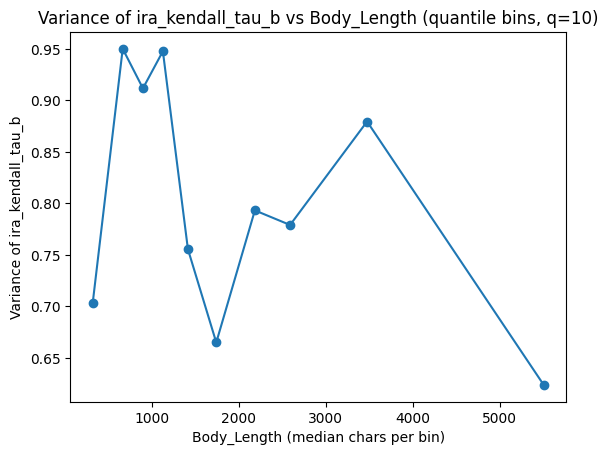

             len_bin   n  len_median  ira_mean   ira_var
0    (99.999, 485.0]  41       319.0  0.398374  0.703220
1     (485.0, 798.0]  41       664.0  0.131707  0.950108
2    (798.0, 1026.5]  40       896.5  0.166667  0.911681
3   (1026.5, 1265.0]  42      1126.0  0.100000  0.947696
4   (1265.0, 1556.0]  39      1414.0  0.376068  0.755436
5   (1556.0, 1997.0]  41      1740.0  0.440650  0.664862
6   (1997.0, 2343.5]  40      2184.0  0.400000  0.793162
7   (2343.5, 2950.0]  41      2589.0  0.268293  0.778997
8   (2950.0, 4125.0]  40      3474.5  0.223611  0.879469
9  (4125.0, 13813.0]  41      5505.0  0.515447  0.623783


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "Ambivalent_Binning_with_IRA.csv"
df = pd.read_csv(FILE_PATH)

LEN_COL = "Body_Length"

# Choose ONE IRA column at a time
IRA_COL = "ira_kendall_tau_b"     # or "ira_spearman_rho"

# Clean
tmp = df[[LEN_COL, IRA_COL]].replace([np.inf, -np.inf], np.nan).dropna()
tmp = tmp[tmp[LEN_COL] > 0]

# ---- Bin by length (quantiles) ----
N_BINS = 10  # try 8, 10, 12
tmp["len_bin"] = pd.qcut(tmp[LEN_COL], q=N_BINS, duplicates="drop")

# Per-bin stats
g = tmp.groupby("len_bin").agg(
    n=(IRA_COL, "count"),
    ira_var=(IRA_COL, "var"),
    ira_mean=(IRA_COL, "mean"),
    len_median=(LEN_COL, "median"),
).reset_index()

# (Optional) drop bins with too few points (variance is noisy when n small)
g = g[g["n"] >= 10].copy()

# Plot variance vs median length
plt.figure()
plt.plot(g["len_median"], g["ira_var"], marker="o")
plt.xlabel("Body_Length (median chars per bin)")
plt.ylabel(f"Variance of {IRA_COL}")
plt.title(f"Variance of {IRA_COL} vs Body_Length (quantile bins, q={N_BINS})")
plt.show()

# If you also want to *see* how many points per bin:
print(g[["len_bin", "n", "len_median", "ira_mean", "ira_var"]])


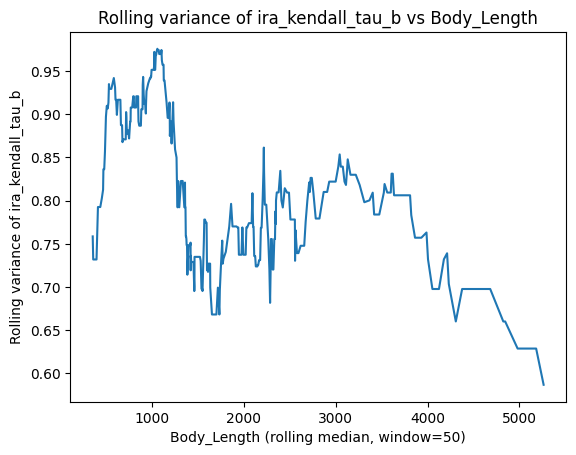

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "Ambivalent_Binning_with_IRA.csv"
df = pd.read_csv(FILE_PATH)

LEN_COL = "Body_Length"
IRA_COL = "ira_kendall_tau_b"  # or "ira_spearman_rho"

tmp = df[[LEN_COL, IRA_COL]].replace([np.inf, -np.inf], np.nan).dropna()
tmp = tmp.sort_values(LEN_COL).reset_index(drop=True)

WINDOW = 50  # try 30, 50, 75
tmp["ira_var_roll"] = tmp[IRA_COL].rolling(WINDOW, min_periods=WINDOW).var()
tmp["len_roll"] = tmp[LEN_COL].rolling(WINDOW, min_periods=WINDOW).median()

plt.figure()
plt.plot(tmp["len_roll"], tmp["ira_var_roll"])
plt.xlabel(f"{LEN_COL} (rolling median, window={WINDOW})")
plt.ylabel(f"Rolling variance of {IRA_COL}")
plt.title(f"Rolling variance of {IRA_COL} vs {LEN_COL}")
plt.show()


/tmp/ipykernel_22377/2673380965.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("len_bin").agg(


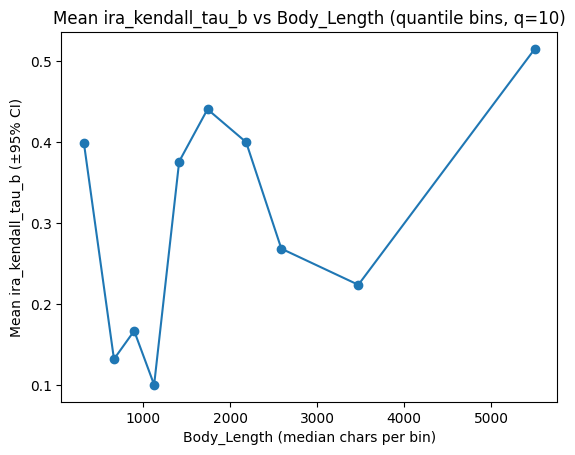

             len_bin   n  len_median  ira_mean   ira_std      ci95
0    (99.999, 485.0]  41       319.0  0.398374  0.838582  0.256690
1     (485.0, 798.0]  41       664.0  0.131707  0.974735  0.298367
2    (798.0, 1026.5]  40       896.5  0.166667  0.954820  0.295902
3   (1026.5, 1265.0]  42      1126.0  0.100000  0.973497  0.294419
4   (1265.0, 1556.0]  39      1414.0  0.376068  0.869158  0.272786
5   (1556.0, 1997.0]  41      1740.0  0.440650  0.815391  0.249592
6   (1997.0, 2343.5]  40      2184.0  0.400000  0.890597  0.275999
7   (2343.5, 2950.0]  41      2589.0  0.268293  0.882608  0.270167
8   (2950.0, 4125.0]  40      3474.5  0.223611  0.937800  0.290627
9  (4125.0, 13813.0]  41      5505.0  0.515447  0.789799  0.241758


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "Ambivalent_Binning_with_IRA.csv"
df = pd.read_csv(FILE_PATH)

LEN_COL = "Body_Length"
IRA_COL = "ira_kendall_tau_b"   # or "ira_spearman_rho"
N_BINS = 10

tmp = df[[LEN_COL, IRA_COL]].replace([np.inf, -np.inf], np.nan).dropna()
tmp = tmp[tmp[LEN_COL] > 0]

tmp["len_bin"] = pd.qcut(tmp[LEN_COL], q=N_BINS, duplicates="drop")

g = tmp.groupby("len_bin").agg(
    n=(IRA_COL, "count"),
    ira_mean=(IRA_COL, "mean"),
    ira_std=(IRA_COL, "std"),
    len_median=(LEN_COL, "median"),
).reset_index()

# 95% CI for mean: mean ± 1.96 * (std/sqrt(n))
g["ira_se"] = g["ira_std"] / np.sqrt(g["n"])
g["ci95"] = 1.96 * g["ira_se"]

plt.figure()
plt.errorbar(g["len_median"], g["ira_mean"], fmt="o-")
plt.xlabel("Body_Length (median chars per bin)")
plt.ylabel(f"Mean {IRA_COL} (±95% CI)")
plt.title(f"Mean {IRA_COL} vs Body_Length (quantile bins, q={N_BINS})")
plt.show()

print(g[["len_bin","n","len_median","ira_mean","ira_std","ci95"]])


## Lexical complexity of posts

In [33]:
import pandas as pd
import re
import shutil
from pathlib import Path

# ====== INPUT FILE ======
FILE_PATH = "Ambivalent_Binning_with_IRA.csv"   # change path if needed
POST_COL = "body"                               # post text column ("body" as you said)

path = Path(FILE_PATH)
if not path.exists():
    raise FileNotFoundError(f"File not found: {path.resolve()}")

# (Optional but recommended) backup before overwriting
backup_path = path.with_suffix(path.suffix + ".bak")
shutil.copyfile(path, backup_path)
print(f"Backup created: {backup_path}")

df = pd.read_csv(path)

_word_re = re.compile(r"[A-Za-z0-9']+")

def ttr(text: str) -> float:
    """
    Type-Token Ratio = (# unique tokens) / (# tokens)
    - Lowercased
    - Simple tokenization with regex
    """
    if pd.isna(text):
        return 0.0
    tokens = _word_re.findall(str(text).lower())
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)

# Add TTR for the post
df["TTR"] = df[POST_COL].apply(ttr)

# Save back to SAME file
df.to_csv(path, index=False)
print(f"Updated file saved (overwritten): {path}")
print("Column added: TTR")


Backup created: Ambivalent_Binning_with_IRA.csv.bak
Updated file saved (overwritten): Ambivalent_Binning_with_IRA.csv
Column added: TTR


In [34]:
import pandas as pd
import numpy as np
from scipy import stats

FILE_PATH = "Ambivalent_Binning_with_IRA.csv"

df = pd.read_csv(FILE_PATH)

X_COL = "TTR"
IRA_COLS = ["ira_kendall_tau_b", "ira_spearman_rho"]  # your IRA metrics

for ira_col in IRA_COLS:
    tmp = df[[X_COL, ira_col]].copy()

    # Clean: drop missing/inf and also drop empty TTR=0 (usually empty body)
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()
    tmp = tmp[tmp[X_COL] > 0]

    x = tmp[X_COL].astype(float).values
    y = tmp[ira_col].astype(float).values

    pearson = stats.pearsonr(x, y)
    spearman = stats.spearmanr(x, y)

    print("\n==============================")
    print(f"Correlation: {X_COL} vs {ira_col}")
    print("N =", len(tmp))
    print(f"Pearson r   = {pearson.statistic:.6f}, p = {pearson.pvalue:.6g}")
    print(f"Spearman ρ  = {spearman.statistic:.6f}, p = {spearman.pvalue:.6g}")



Correlation: TTR vs ira_kendall_tau_b
N = 406
Pearson r   = -0.041585, p = 0.403324
Spearman ρ  = -0.049855, p = 0.316311

Correlation: TTR vs ira_spearman_rho
N = 406
Pearson r   = -0.041032, p = 0.409612
Spearman ρ  = -0.049471, p = 0.320052


## Length of posts (Word)

In [35]:
import pandas as pd
import re
import shutil
from pathlib import Path

# ====== INPUT FILE ======
FILE_PATH = "Ambivalent_Binning_with_IRA.csv"   # change path if needed
POST_COL = "body"                               # post text column

path = Path(FILE_PATH)
if not path.exists():
    raise FileNotFoundError(f"File not found: {path.resolve()}")

# (Optional but recommended) backup before overwriting
backup_path = path.with_suffix(path.suffix + ".bak")
shutil.copyfile(path, backup_path)
print(f"Backup created: {backup_path}")

df = pd.read_csv(path)

_word_re = re.compile(r"[A-Za-z0-9']+")

def word_count(text) -> int:
    """Counts word-like tokens using a simple regex tokenizer."""
    if pd.isna(text):
        return 0
    tokens = _word_re.findall(str(text))
    return len(tokens)

# Add Word_Count for the post
df["Word_Count"] = df[POST_COL].apply(word_count)

# Save back to SAME file
df.to_csv(path, index=False)
print(f"Updated file saved (overwritten): {path}")
print("Column added: Word_Count")


Backup created: Ambivalent_Binning_with_IRA.csv.bak
Updated file saved (overwritten): Ambivalent_Binning_with_IRA.csv
Column added: Word_Count


In [36]:
import pandas as pd
import numpy as np
from scipy import stats

FILE_PATH = "Ambivalent_Binning_with_IRA.csv"

df = pd.read_csv(FILE_PATH)

X_COL = "Word_Count"
IRA_COLS = ["ira_kendall_tau_b", "ira_spearman_rho"]

for ira_col in IRA_COLS:
    tmp = df[[X_COL, ira_col]].copy()

    # Clean
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()
    tmp = tmp[tmp[X_COL] > 0]  # drop empty posts (0 words)

    x = tmp[X_COL].astype(float).values
    y = tmp[ira_col].astype(float).values

    pearson = stats.pearsonr(x, y)
    spearman = stats.spearmanr(x, y)

    print("\n==============================")
    print(f"Correlation: {X_COL} vs {ira_col}")
    print("N =", len(tmp))
    print(f"Pearson r   = {pearson.statistic:.6f}, p = {pearson.pvalue:.6g}")
    print(f"Spearman ρ  = {spearman.statistic:.6f}, p = {spearman.pvalue:.6g}")



Correlation: Word_Count vs ira_kendall_tau_b
N = 406
Pearson r   = 0.073206, p = 0.140888
Spearman ρ  = 0.054519, p = 0.273099

Correlation: Word_Count vs ira_spearman_rho
N = 406
Pearson r   = 0.070950, p = 0.15358
Spearman ρ  = 0.054124, p = 0.276589


## Lexical complexity of comments

In [37]:
import pandas as pd
import numpy as np
import re
from scipy import stats
import matplotlib.pyplot as plt


In [38]:
FILE_PATH = "Ambivalent_Binning_with_IRA.csv"

df = pd.read_csv(FILE_PATH)

BIN_COLS = [f"bin{str(i).zfill(2)}_comment" for i in range(1, 11)]
RANK_COL_LLM = "LLM_Ranking"
RANK_COL_HUM = "Human_Ranking"

print("Shape:", df.shape)
print("Columns check:",
      all(c in df.columns for c in BIN_COLS),
      RANK_COL_LLM in df.columns,
      RANK_COL_HUM in df.columns)


Shape: (407, 36)
Columns check: True True True


In [39]:
_word_re = re.compile(r"[A-Za-z0-9']+")

def tokenize(text: str):
    if pd.isna(text):
        return []
    return _word_re.findall(str(text).lower())

def ttr(text: str) -> float:
    toks = tokenize(text)
    if not toks:
        return 0.0
    return len(set(toks)) / len(toks)

def word_count(text: str) -> int:
    return len(tokenize(text))

def parse_ranking_to_list(x):
    """
    Turns a ranking string into a list of integers.
    Works with formats like:
      "1,2,3"
      "[1, 2, 3]"
      "1 > 2 > 3"
      "bin01, bin02, bin03" (extracts numbers)
    Returns [] if cannot parse.
    """
    if pd.isna(x):
        return []
    s = str(x).strip()

    # Extract all integers from the string
    nums = re.findall(r"\d+", s)
    if not nums:
        return []
    return [int(n) for n in nums]


In [40]:
base_cols = ["post_id", "subreddit", "title", "permalink", RANK_COL_LLM, RANK_COL_HUM]

long_df = df[base_cols + BIN_COLS].melt(
    id_vars=base_cols,
    value_vars=BIN_COLS,
    var_name="bin_col",
    value_name="comment_text"
)

# bin index: bin01_comment -> 1, etc.
long_df["bin_idx"] = long_df["bin_col"].str.extract(r"bin(\d+)_comment").astype(int)

# drop empty comments
long_df["comment_text"] = long_df["comment_text"].fillna("").astype(str)
long_df = long_df[long_df["comment_text"].str.strip() != ""].copy()

print("Long shape (non-empty comments):", long_df.shape)
long_df.head(3)


Long shape (non-empty comments): (942, 9)


,post_id,subreddit,title,permalink,LLM_Ranking,Human_Ranking,bin_col,comment_text,bin_idx
0,1hv4zdy,meToo,Was this SA?,/r/meToo/comments/1hv4zdy/was_this_sa/,"1,2","2,1",bin01_comment,"As a woman who has been SA’d multiple times, I...",1
1,1bautv8,meToo,Not sure if this counts as SA,/r/meToo/comments/1bautv8/not_sure_if_this_cou...,"2,1","2,1",bin01_comment,"I’m so sorry this happened to you, I definitel...",1
2,11f4o14,meToo,just a rant,/r/meToo/comments/11f4o14/just_a_rant/,"1,2","2,1",bin01_comment,One should never have sex before one WANTS to....,1


In [41]:
# Parse lists per post
rank_map = df[["post_id", RANK_COL_LLM, RANK_COL_HUM]].copy()
rank_map["llm_list"] = rank_map[RANK_COL_LLM].apply(parse_ranking_to_list)
rank_map["human_list"] = rank_map[RANK_COL_HUM].apply(parse_ranking_to_list)

# Turn list into dict: bin_idx -> rank_position
def list_to_pos_map(lst):
    # If list is [2,1,3], that means bin2 is rank1, bin1 is rank2, bin3 is rank3
    return {bin_idx: pos for pos, bin_idx in enumerate(lst, start=1)}

rank_map["llm_pos_map"] = rank_map["llm_list"].apply(list_to_pos_map)
rank_map["human_pos_map"] = rank_map["human_list"].apply(list_to_pos_map)

# Merge into long_df
long_df = long_df.merge(rank_map[["post_id", "llm_pos_map", "human_pos_map"]], on="post_id", how="left")

# Map each comment bin_idx to its rank position
long_df["llm_rank_pos"] = long_df.apply(lambda r: r["llm_pos_map"].get(r["bin_idx"], np.nan), axis=1)
long_df["human_rank_pos"] = long_df.apply(lambda r: r["human_pos_map"].get(r["bin_idx"], np.nan), axis=1)

# Keep only rows where LLM assigned a rank position
long_df = long_df.dropna(subset=["llm_rank_pos"]).copy()
long_df["llm_rank_pos"] = long_df["llm_rank_pos"].astype(int)

print("After mapping LLM ranks:", long_df.shape)
long_df[["post_id","bin_idx","llm_rank_pos","human_rank_pos"]].head(10)


After mapping LLM ranks: (942, 13)


,post_id,bin_idx,llm_rank_pos,human_rank_pos
0,1hv4zdy,1,1,2
1,1bautv8,1,2,2
2,11f4o14,1,1,2
3,10olxi4,1,2,2
4,104hhnz,1,1,2
5,xyf4l9,1,2,2
6,w2py1z,1,2,2
7,v3hktm,1,2,2
8,jafsse,1,2,2
9,1ofr7sg,1,1,2


In [42]:
long_df["comment_word_count"] = long_df["comment_text"].apply(word_count)
long_df["comment_ttr"] = long_df["comment_text"].apply(ttr)

# Drop super-short comments if you want (optional)
# long_df = long_df[long_df["comment_word_count"] >= 3].copy()

long_df[["comment_word_count","comment_ttr"]].describe()


,comment_word_count,comment_ttr
count,942.000000,942.000000
mean,40.493631,0.845350
std,24.982575,0.108092
min,0.000000,0.000000
25%,17.000000,0.762107
50%,43.000000,0.833333
75%,65.000000,0.933333
max,80.000000,1.000000


In [43]:
def per_post_spearman(group, x_col):
    # Spearman between LLM rank position and complexity metric
    # Need at least 3 ranked comments to correlate
    if group.shape[0] < 2:
        return np.nan
    rho, p = stats.spearmanr(group["llm_rank_pos"], group[x_col])
    return rho

posts = []
for post_id, g in long_df.groupby("post_id"):
    rho_ttr = per_post_spearman(g, "comment_ttr")
    rho_wc  = per_post_spearman(g, "comment_word_count")
    n = g.shape[0]
    posts.append((post_id, n, rho_ttr, rho_wc))

post_corr = pd.DataFrame(posts, columns=["post_id","n_comments","rho_rank_vs_ttr","rho_rank_vs_wordcount"])
post_corr = post_corr.dropna(subset=["rho_rank_vs_ttr","rho_rank_vs_wordcount"], how="all")

print("Posts with usable per-post correlations:", len(post_corr))
post_corr.describe()


/tmp/ipykernel_22377/1549397405.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(group["llm_rank_pos"], group[x_col])


Posts with usable per-post correlations: 403


,n_comments,rho_rank_vs_ttr,rho_rank_vs_wordcount
count,403.000000,392.000000,396.000000
mean,2.317618,0.352781,-0.401308
std,0.854233,0.883361,0.866448
min,2.000000,-1.000000,-1.000000
25%,2.000000,-1.000000,-1.000000
50%,2.000000,1.000000,-1.000000
75%,2.000000,1.000000,0.800000
max,10.000000,1.000000,1.000000


In [44]:
def summarize(col):
    s = post_corr[col].dropna()
    return {
        "n_posts": len(s),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "std": float(s.std()),
        "pct_negative": float((s < 0).mean()),
        "pct_positive": float((s > 0).mean()),
    }

print("Within-post Spearman: rank_pos vs TTR")
print(summarize("rho_rank_vs_ttr"))

print("\nWithin-post Spearman: rank_pos vs word_count")
print(summarize("rho_rank_vs_wordcount"))


Within-post Spearman: rank_pos vs TTR
{'n_posts': 392, 'mean': 0.3527812369360686, 'median': 0.9999999999999999, 'std': 0.8833614639309981, 'pct_negative': 0.3163265306122449, 'pct_positive': 0.6785714285714286}

Within-post Spearman: rank_pos vs word_count
{'n_posts': 396, 'mean': -0.40130807895247433, 'median': -0.9999999999999999, 'std': 0.8664478261201194, 'pct_negative': 0.7070707070707071, 'pct_positive': 0.2878787878787879}
